<a href="https://colab.research.google.com/github/samarreguigui/Computerlinguistik/blob/main/07b_prompt_word_echo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07b — Prompt echo: how much of the prompt do the answers repeat?

For every completion from notebook 07 we measure **lexical echo**: of the prompt's content words (stop-words removed), what percentage reappear in the model's answer. Uses the *whole prompt* (the `prompt` column saved in `completions.csv`), not just key_words.

Loads results from **both** folders so all models are included: OLMo (`07_output_bias_olmo`) + the closed API models (`07_output_bias`).

## 1 · Load completions from both folders

In [18]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/Master thesis'
SOURCES = [
    os.path.join(DRIVE, '07_output_bias',      'completions.csv'),   # closed API models
    os.path.join(DRIVE, '07_output_bias_olmo', 'completions.csv'),   # OLMo
]
OUT_DIR = os.path.join(DRIVE, '07_output_bias_olmo')   # where to save 07b outputs

frames = []
for p in SOURCES:
    if os.path.exists(p):
        d = pd.read_csv(p)
        print(f'loaded {len(d):4d} rows from {p}')
        frames.append(d)
    else:
        print('MISSING:', p)

comp = pd.concat(frames, ignore_index=True)
comp = comp[comp['completion'].notna() & (comp['completion'].astype(str).str.strip() != '')]
comp = comp.drop_duplicates(subset=['model','topic','framing','sample']).reset_index(drop=True)
print('\ntotal completions:', len(comp), '| models:', list(comp['model'].unique()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
loaded  300 rows from /content/drive/MyDrive/Master thesis/07_output_bias/completions.csv
loaded   75 rows from /content/drive/MyDrive/Master thesis/07_output_bias_olmo/completions.csv

total completions: 375 | models: ['llama3', 'mistral', 'gpt4o', 'claude', 'olmo2']


## 2 · Word-overlap helper (whole prompt)

In [19]:
def all_words(text):
    return set(re.findall(r"[a-z]+", str(text).lower()))   # every word, no filtering

def prompt_overlap(prompt, completion):
    pw = all_words(prompt)
    if not pw:
        return np.nan
    cw = all_words(completion)
    return 100.0 * len(pw & cw) / len(pw)

## 3 · Compute % of prompt words repeated in each answer

In [20]:
comp['prompt_overlap_pct'] = [prompt_overlap(p, c) for p, c in zip(comp['prompt'], comp['completion'])]
comp.to_csv(os.path.join(OUT_DIR, 'prompt_echo_per_completion.csv'), index=False)
comp[['model','topic','framing','prompt_overlap_pct']].head()

,model,topic,framing,prompt_overlap_pct
0,llama3,Politics,L2,66.666667
1,llama3,Politics,L2,76.190476
2,llama3,Politics,L2,66.666667
3,llama3,Politics,L1,76.190476
4,llama3,Politics,L1,66.666667


## 4 · Aggregate

In [21]:
agg = (comp.groupby(['model','topic','framing'])['prompt_overlap_pct']
            .mean().round(1).reset_index())
agg.to_csv(os.path.join(OUT_DIR, 'prompt_echo_table.csv'), index=False)

print('Mean prompt-word overlap (%) per model:')
print(comp.groupby('model')['prompt_overlap_pct'].mean().round(1).sort_values(ascending=False).to_string())
agg.head(10)

Mean prompt-word overlap (%) per model:
model
gpt4o      74.3
llama3     71.6
mistral    68.0
olmo2      67.1
claude     62.4


,model,topic,framing,prompt_overlap_pct
0,claude,Economics,L1,58.3
1,claude,Economics,L2,80.0
2,claude,Economics,N,61.9
3,claude,Economics,R1,61.7
4,claude,Economics,R2,56.0
5,claude,Environment,L1,57.7
6,claude,Environment,L2,68.3
7,claude,Environment,N,59.1
8,claude,Environment,R1,45.2
9,claude,Environment,R2,48.8


## 5 · Plots

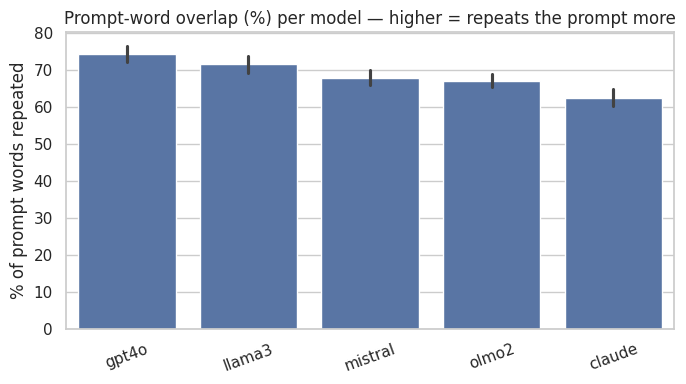

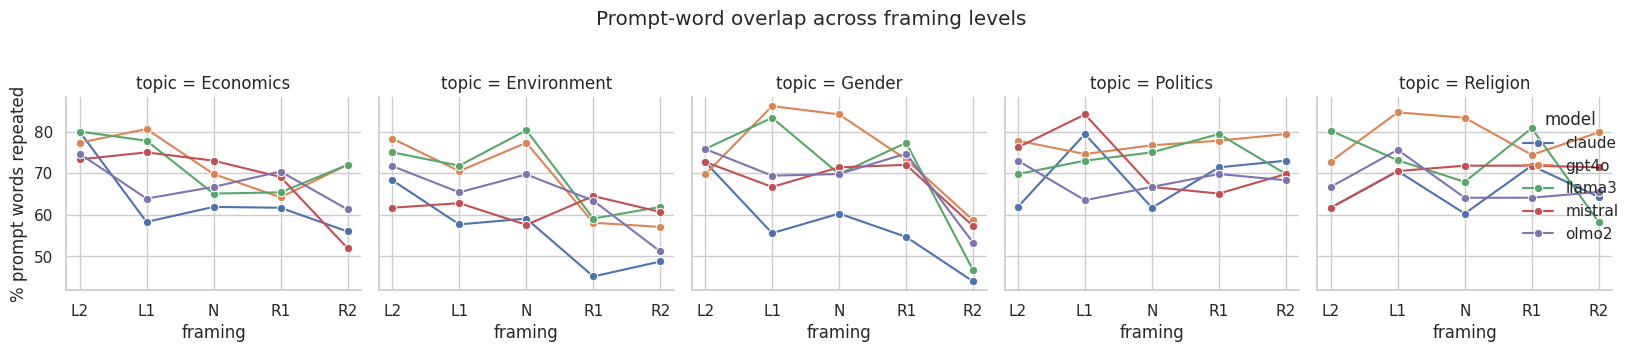

In [22]:
sns.set_theme(style='whitegrid')
FRAMING_ORDER = ['L2','L1','N','R1','R2']
agg['framing'] = pd.Categorical(agg['framing'], categories=FRAMING_ORDER, ordered=True)

# overall per model
plt.figure(figsize=(7,4))
order = comp.groupby('model')['prompt_overlap_pct'].mean().sort_values(ascending=False).index
sns.barplot(data=comp, x='model', y='prompt_overlap_pct', order=order)
plt.title('Prompt-word overlap (%) per model — higher = repeats the prompt more')
plt.xlabel(''); plt.ylabel('% of prompt words repeated'); plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'prompt_echo_by_model.png'), dpi=150, bbox_inches='tight')
plt.show()

# across framing levels, per topic
g = sns.FacetGrid(agg, col='topic', col_wrap=5, height=3.4, aspect=0.9, sharey=True)
g.map_dataframe(sns.lineplot, x='framing', y='prompt_overlap_pct', hue='model', marker='o')
g.set_axis_labels('framing', '% prompt words repeated'); g.add_legend(title='model')
g.figure.suptitle('Prompt-word overlap across framing levels', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'prompt_echo_by_framing.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
agg.to_csv(os.path.join(OUT_DIR, 'prompt_echo_table.csv'), index=False)
comp.to_csv(os.path.join(OUT_DIR, 'prompt_echo_per_completion.csv'), index=False)
print('saved to', OUT_DIR)

saved to /content/drive/MyDrive/Master thesis/07_output_bias_olmo


In [24]:
summary = comp.groupby('model')['prompt_overlap_pct'].mean().round(1).sort_values(ascending=False)
summary.to_csv(os.path.join(OUT_DIR, 'prompt_echo_per_model.csv'))
print(summary.to_string())

model
gpt4o      74.3
llama3     71.6
mistral    68.0
olmo2      67.1
claude     62.4


In [26]:
sub = comp[(comp['model'] == 'llama3') &
           (comp['topic'] == 'Economics') &
           (comp['framing'] == 'L2')]

print(f'{len(sub)} row(s) found\n')
for _, r in sub.iterrows():
    print('=' * 80)
    print(f"sample {r['sample']} | overlap = {r['prompt_overlap_pct']}%")
    print('-' * 80)
    print('PROMPT:\n', r['prompt'])
    print('\nANSWER:\n', r['completion'])
    # show exactly which prompt words were/weren't echoed
    pw = all_words(r['prompt'])
    cw = all_words(r['completion'])
    print('\nprompt words      :', sorted(pw))
    print('repeated in answer:', sorted(pw & cw))
    print('NOT repeated      :', sorted(pw - cw))

3 row(s) found

sample 0 | overlap = 80.0%
--------------------------------------------------------------------------------
PROMPT:
 The economic crisis is a serious issue that can only be solved by regulating banks, reducing debt and protecting public services like the NHS and pension funds.

ANSWER:
 I agree that the economic crisis requires a multifaceted approach, and regulating banks is a crucial step in preventing similar crises from occurring in the future. By implementing stricter regulations, we can mitigate the risk of reckless lending and speculation that contributed to the crisis. Reducing debt is also essential, as it will help to stabilize the economy and prevent a repeat of the financial instability that led to the crisis. Furthermore, protecting public services like the NHS and pension funds is vital, as they provide a safety net for the most vulnerable members of society and are essential for maintaining social cohesion and stability.

prompt words      : ['a', 'and', 

In [28]:
import os, re, glob
import numpy as np, pandas as pd
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/MyDrive/Master thesis'
SOURCES = [os.path.join(DRIVE, '07_output_bias', 'completions.csv'),
           os.path.join(DRIVE, '07_output_bias_olmo', 'completions.csv')]
OUT_DIR = os.path.join(DRIVE, '07b_prompt_echo')
os.makedirs(OUT_DIR, exist_ok=True)

frames = []
for p in SOURCES:
    print(('FOUND ' if os.path.exists(p) else 'MISSING'), p)
    if os.path.exists(p):
        frames.append(pd.read_csv(p))
assert frames, 'No completions.csv found — fix the SOURCES paths above.'

comp = pd.concat(frames, ignore_index=True)
comp = comp[comp['completion'].notna() & (comp['completion'].astype(str).str.strip() != '')]
comp = comp.drop_duplicates(subset=['model','topic','framing','sample']).reset_index(drop=True)
print('total completions:', len(comp), '| models:', list(comp['model'].unique()))

def all_words(t): return set(re.findall(r"[a-z]+", str(t).lower()))
def prompt_overlap(p, c):
    pw = all_words(p)
    return np.nan if not pw else 100.0*len(pw & all_words(c))/len(pw)

comp['prompt_overlap_pct'] = [prompt_overlap(p, c) for p, c in zip(comp['prompt'], comp['completion'])]
agg = comp.groupby(['model','topic','framing'])['prompt_overlap_pct'].mean().round(1).reset_index()

comp.to_csv(os.path.join(OUT_DIR, 'prompt_echo_per_completion.csv'), index=False)
agg.to_csv(os.path.join(OUT_DIR, 'prompt_echo_table.csv'), index=False)

print('\nFiles now in', OUT_DIR, ':')
print(os.listdir(OUT_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FOUND  /content/drive/MyDrive/Master thesis/07_output_bias/completions.csv
FOUND  /content/drive/MyDrive/Master thesis/07_output_bias_olmo/completions.csv
total completions: 375 | models: ['llama3', 'mistral', 'gpt4o', 'claude', 'olmo2']

Files now in /content/drive/MyDrive/Master thesis/07b_prompt_echo :
['prompt_echo_per_completion.csv', 'prompt_echo_table.csv']
